# Lahore Societies Map + Average Prices (Folium)

This notebook scans society maps in `../societies`, aggregates average listing prices from `../data` (Graana + Zameen), and renders an interactive Folium map saved to `../dha_price_heatmap.html`.

Steps:
- Discover shapefiles in `../societies/**/*.shp`
- Load scraped CSVs, parse prices to PKR, and compute per-society averages
- Join averages to society polygons and render a choropleth + popups


In [6]:
# Imports and paths
import os
# %pip install geopandas
import re
# %pip install folium
import math
import json
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
from folium.features import GeoJsonTooltip

# Paths (notebook lives in notebooks/)
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
SOCIETIES_DIR = ROOT / 'societies'
OUTPUT_MAP = ROOT / 'dha_price_heatmap2.html'

# Helper: clean price strings to numeric PKR
PRICE_PATTERNS = [
    (re.compile(r"([0-9]*\.?[0-9]+)\s*(crore|cr)\b", re.I), 1e7),
    (re.compile(r"([0-9]*\.?[0-9]+)\s*(million|m)\b", re.I), 1e6),
    (re.compile(r"([0-9]*\.?[0-9]+)\s*(lac|lakh|lac\.)\b", re.I), 1e5),
]

def parse_price_to_pkr(x):
    if pd.isna(x):
        return math.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().replace(',', '')
    # pure number
    try:
        return float(s)
    except ValueError:
        pass
    for pat, mult in PRICE_PATTERNS:
        m = pat.search(s)
        if m:
            return float(m.group(1)) * mult
    # plain PKR like 12345678 or with Rs
    m2 = re.search(r"([0-9]{3,})", s)
    if m2:
        return float(m2.group(1))
    return math.nan

# Helper: normalized society name from text
NORMALIZE_RE = re.compile(r"[^a-z0-9]+")

def normalize_name(s):
    if pd.isna(s):
        return None
    return NORMALIZE_RE.sub('-', str(s).lower()).strip('-')


In [2]:
# Discover shapefiles under societies directory
shp_paths = []
for root, dirs, files in os.walk(SOCIETIES_DIR):
    for f in files:
        if f.lower().endswith('.shp'):
            shp_paths.append(Path(root) / f)

if not shp_paths:
    print('No shapefiles found in', SOCIETIES_DIR)

# Load all shapefiles into a single GeoDataFrame
frames = []
for p in shp_paths:
    try:
        gdf = gpd.read_file(p)
        gdf = gdf.to_crs(epsg=4326) if gdf.crs is not None else gdf.set_crs(4326, allow_override=True)
        # derive society label from relative folder under societies/
        rel = p.relative_to(SOCIETIES_DIR)
        # take top-level subdir or second if first is common like 'DHA'
        parts = rel.parts
        if len(parts) >= 2:
            candidate = parts[0]
            # If first is a generic grouping like 'DHA' or 'Private Schemes', try second
            if candidate.lower() in {'dha', 'private schemes'}:
                candidate = parts[1]
        else:
            candidate = p.stem
        gdf['society_label'] = candidate
        gdf['society_key'] = normalize_name(candidate)
        gdf['source_path'] = str(p)
        frames.append(gdf)
    except Exception as e:
        print('Failed to read', p, e)

societies_gdf = pd.concat(frames, ignore_index=True) if frames else gpd.GeoDataFrame(columns=['geometry','society_label','society_key','source_path'], geometry='geometry', crs='EPSG:4326')
print('Society polygons:', len(societies_gdf))


Failed to read D:\LUMS\Senior Fall 25\SPROJ - Dr Tahir\SPROJ\societies\DHA\Merged_PCT_Vectorized.shp Unable to allocate 201. MiB for an array with shape (13173080, 2) and data type float64
Society polygons: 66049


In [3]:
# Load scraped data and compute per-society averages
csv_candidates = [
    DATA_DIR / 'zameen_lahore_data.csv',
    DATA_DIR / 'graana_lahore_data.csv',
    DATA_DIR / 'raw_data_zameen.csv',
]
frames = []
for p in csv_candidates:
    if p.exists():
        try:
            df = pd.read_csv(p)
            df['__source_csv'] = p.name
            frames.append(df)
        except Exception as e:
            print('Failed to read CSV', p, e)

listings = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print('Listings rows:', len(listings))

# infer columns for society and price
society_col = None
for c in listings.columns if not listings.empty else []:
    cl = c.lower()
    if cl in {'society', 'society_name', 'area', 'location', 'locality'}:
        society_col = c
        break
if society_col is None and not listings.empty:
    # try to split a location like 'DHA Phase 5 Lahore'
    society_col = 'location'
    if 'location' not in listings.columns:
        society_col = listings.columns[0]

price_col = None
for c in listings.columns if not listings.empty else []:
    cl = c.lower()
    if cl in {'price', 'price_pkr', 'asking_price', 'amount'}:
        price_col = c
        break
if price_col is None and not listings.empty:
    # best guess
    price_col = listings.columns[-1]

if not listings.empty:
    listings['society_label_raw'] = listings[society_col].astype(str)
    listings['society_key'] = listings['society_label_raw'].map(normalize_name)
    listings['price_pkr'] = listings[price_col].map(parse_price_to_pkr)

    price_stats = (
        listings
        .dropna(subset=['society_key','price_pkr'])
        .groupby('society_key', as_index=False)
        .agg(avg_price_pkr=('price_pkr','mean'), count=('price_pkr','size'))
    )
else:
    price_stats = pd.DataFrame(columns=['society_key','avg_price_pkr','count'])

print('Societies with prices:', len(price_stats))


Listings rows: 5865
Societies with prices: 779


In [5]:
# Join polygons with price averages
if not societies_gdf.empty:
    gdf_joined = societies_gdf.merge(price_stats, on='society_key', how='left')

    # Keep only safe, needed columns to avoid non-JSON-serializable properties
    wanted = ['geometry', 'society_label', 'avg_price_pkr', 'count', 'source_path']
    cols = [c for c in wanted if c in gdf_joined.columns]
    gdf_use = gdf_joined.loc[:, cols].copy()
    if 'society_label' in gdf_use:
        gdf_use['society_label'] = gdf_use['society_label'].astype(str)
    if 'source_path' in gdf_use:
        gdf_use['source_path'] = gdf_use['source_path'].astype(str)
    for c in ['avg_price_pkr', 'count']:
        if c in gdf_use:
            gdf_use[c] = pd.to_numeric(gdf_use[c], errors='coerce')
    gdf_use = gdf_use[gdf_use.geometry.notnull()]

    # center map on overall centroid
    if not gdf_use.empty and gdf_use.geometry.notnull().any():
        center = gdf_use.to_crs(4326).unary_union.centroid
        m_center = [center.y, center.x]
    else:
        m_center = [31.5204, 74.3587]  # Lahore fallback

    m = folium.Map(location=m_center, zoom_start=11, tiles='cartodbpositron')

    # Precompute bins
    vals = gdf_use['avg_price_pkr'].dropna()
    if len(vals) >= 5:
        bins = list(vals.quantile([0.2,0.4,0.6,0.8]).values)
    elif len(vals) > 0:
        bins = sorted(vals.unique().tolist())
    else:
        bins = []

    def color_for(v):
        if pd.isna(v):
            return '#cccccc'
        palette = ['#fee5d9','#fcae91','#fb6a4a','#de2d26','#a50f15']
        if not bins:
            return '#cccccc'
        idx = 0
        for b in bins:
            if v <= b:
                break
            idx += 1
        idx = max(0, min(idx, len(palette)-1))
        return palette[idx]

    gj = folium.GeoJson(
        gdf_use,
        name='Societies',
        style_function=lambda feat: {
            'fillOpacity': 0.6,
            'weight': 0.8,
            'color': '#555555',
            'fillColor': color_for(feat['properties'].get('avg_price_pkr')),
        },
        tooltip=GeoJsonTooltip(fields=[f for f in ['society_label','avg_price_pkr','count'] if f in gdf_use.columns],
                               aliases=['Society','Avg Price (PKR)','Listings'][:len([f for f in ['society_label','avg_price_pkr','count'] if f in gdf_use.columns])],
                               localize=True),
        popup=folium.GeoJsonPopup(fields=[f for f in ['society_label','avg_price_pkr','count','source_path'] if f in gdf_use.columns],
                                  aliases=['Society','Avg Price (PKR)','Listings','Shapefile'][:len([f for f in ['society_label','avg_price_pkr','count','source_path'] if f in gdf_use.columns])])
    )
    gj.add_to(m)

    # Add a legend
    palette = ['#fee5d9','#fcae91','#fb6a4a','#de2d26','#a50f15']
    entries = []
    for i, c in enumerate(palette):
        if not bins:
            label = 'No data'
        elif i < len(bins):
            label = f"≤ {bins[i]:,.0f}"
        else:
            label = f"> {bins[-1]:,.0f}"
        entries.append(f'<i style="background:{c};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>')

    legend_html = f'''<div style="position: fixed; bottom: 20px; left: 20px; z-index: 9999; background: white; padding: 10px; border: 1px solid #ccc;">
    <b>Avg Price (PKR)</b><br>
    {''.join(entries)}
    </div>'''
    m.get_root().html.add_child(folium.Element(legend_html))

    m.save(str(OUTPUT_MAP))
    m
else:
    print('No society polygons to map.')


C:\Users\H.T\AppData\Local\Temp\ipykernel_6000\2944576032.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf_use.to_crs(4326).unary_union.centroid


In [1]:
# Find candidate GeoTIFF files to inspect
from pathlib import Path

ROOT = Path('..').resolve()
TIF_DIRS = [ROOT / 'societies' / 'DHA']

candidates = []
for d in TIF_DIRS:
    if d.exists():
        for p in d.rglob('*.tif'):
            candidates.append(p)

# Prefer specific filenames if available
preferred = ['Merged.tif', 'Merged_PCT.tif']
chosen = None
for name in preferred:
    for p in candidates:
        if p.name.lower() == name.lower():
            chosen = p
            break
    if chosen:
        break

if chosen is None and candidates:
    # Fallback to the largest file (likely most interesting raster)
    try:
        chosen = max(candidates, key=lambda p: p.stat().st_size)
    except Exception:
        chosen = candidates[0]

print(f"Found {len(candidates)} GeoTIFF(s)")
print("Chosen:", chosen)
TIF_CHOSEN = chosen

Found 88 GeoTIFF(s)
Chosen: D:\LUMS\Senior Fall 25\SPROJ - Dr Tahir\SPROJ\societies\DHA\Merged.tif


In [12]:
# Inspect GeoTIFF metadata
import rasterio as rio
from rasterio.plot import reshape_as_image

if 'TIF_CHOSEN' not in globals() or TIF_CHOSEN is None:
    raise RuntimeError('No GeoTIFF selected (run the discovery cell first).')

print('Opening:', TIF_CHOSEN)
with rio.open(TIF_CHOSEN) as src:
    # print('CRS:', src.crs)
    # print('Bounds:', src.bounds)
    # print('Transform:', src.transform)
    # print('Size (width x height):', src.width, 'x', src.height)
    # print('Band count:', src.count)
    # print('Dtype:', src.dtypes)
    # print('Nodata:', src.nodata)
    # print('Driver:', src.driver)

    # # Per-band stats (sample window to avoid heavy reads)
    # try:
    #     # read a small window (center 1024x1024 or smaller)
    #     w = min(1024, src.width)
    #     h = min(1024, src.height)
    #     col_off = max(0, (src.width - w)//2)
    #     row_off = max(0, (src.height - h)//2)
    #     window = rio.windows.Window(col_off, row_off, w, h)
    #     sample = src.read(out_shape=(src.count, h, w), window=window, resampling=rio.enums.Resampling.nearest)
    #     print('Sample window shape:', sample.shape)
    #     print('Sample min/max per band:', [ (float(s.min()), float(s.max())) for s in sample ])
    # except Exception as e:
    #     print('Sample read skipped:', e)
    print("Metadata:")
    for key, value in src.meta.items():
        print(f"  {key}: {value}")

    print("\nTags:")
    for key, value in src.tags().items():
        print(f"  {key}: {value}")


Opening: D:\LUMS\Senior Fall 25\SPROJ - Dr Tahir\SPROJ\societies\DHA\Merged.tif
Metadata:
  driver: GTiff
  dtype: float32
  nodata: None
  width: 7167
  height: 5686
  count: 4
  crs: EPSG:3857
  transform: | 2.39, 0.00, 8277229.45|
| 0.00,-2.39, 3702301.68|
| 0.00, 0.00, 1.00|

Tags:
  AREA_OR_POINT: Area


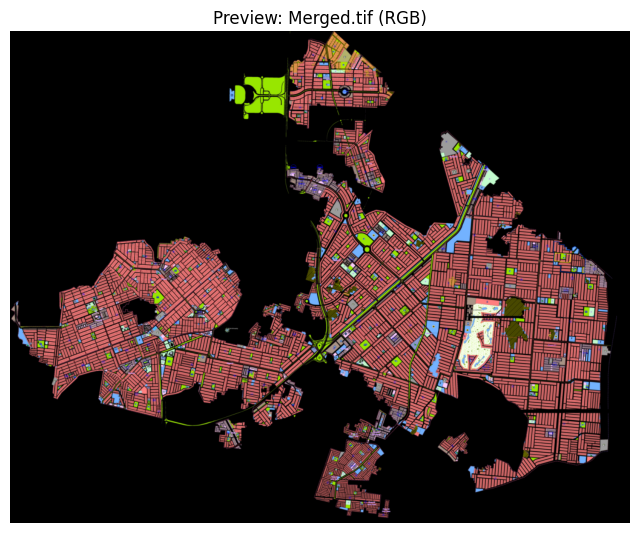

In [3]:
# Preview image (downsampled)
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.plot import reshape_as_image

if 'TIF_CHOSEN' not in globals() or TIF_CHOSEN is None:
    raise RuntimeError('No GeoTIFF selected (run discovery cell first).')

with rio.open(TIF_CHOSEN) as src:
    scale = max(src.width, src.height) / 1024
    out_w = int(src.width / scale)
    out_h = int(src.height / scale)

    data = src.read(
        out_shape=(src.count, out_h, out_w),
        resampling=Resampling.bilinear
    )

    # Normalize to 0-1 for display
    data = data.astype('float32')
    if data.max() > 1:
        data /= 255.0

    if src.count >= 3:
        img = reshape_as_image(data[:3])  # RGB
        plt.figure(figsize=(8, 8))
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f'Preview: {TIF_CHOSEN.name} (RGB)')
        plt.axis('off')
        plt.show()
    else:
        img = data[0]
        plt.figure(figsize=(8, 8))
        plt.imshow(img, cmap='gray')
        plt.title(f'Preview: {TIF_CHOSEN.name} (Band 1)')
        plt.axis('off')
        plt.show()


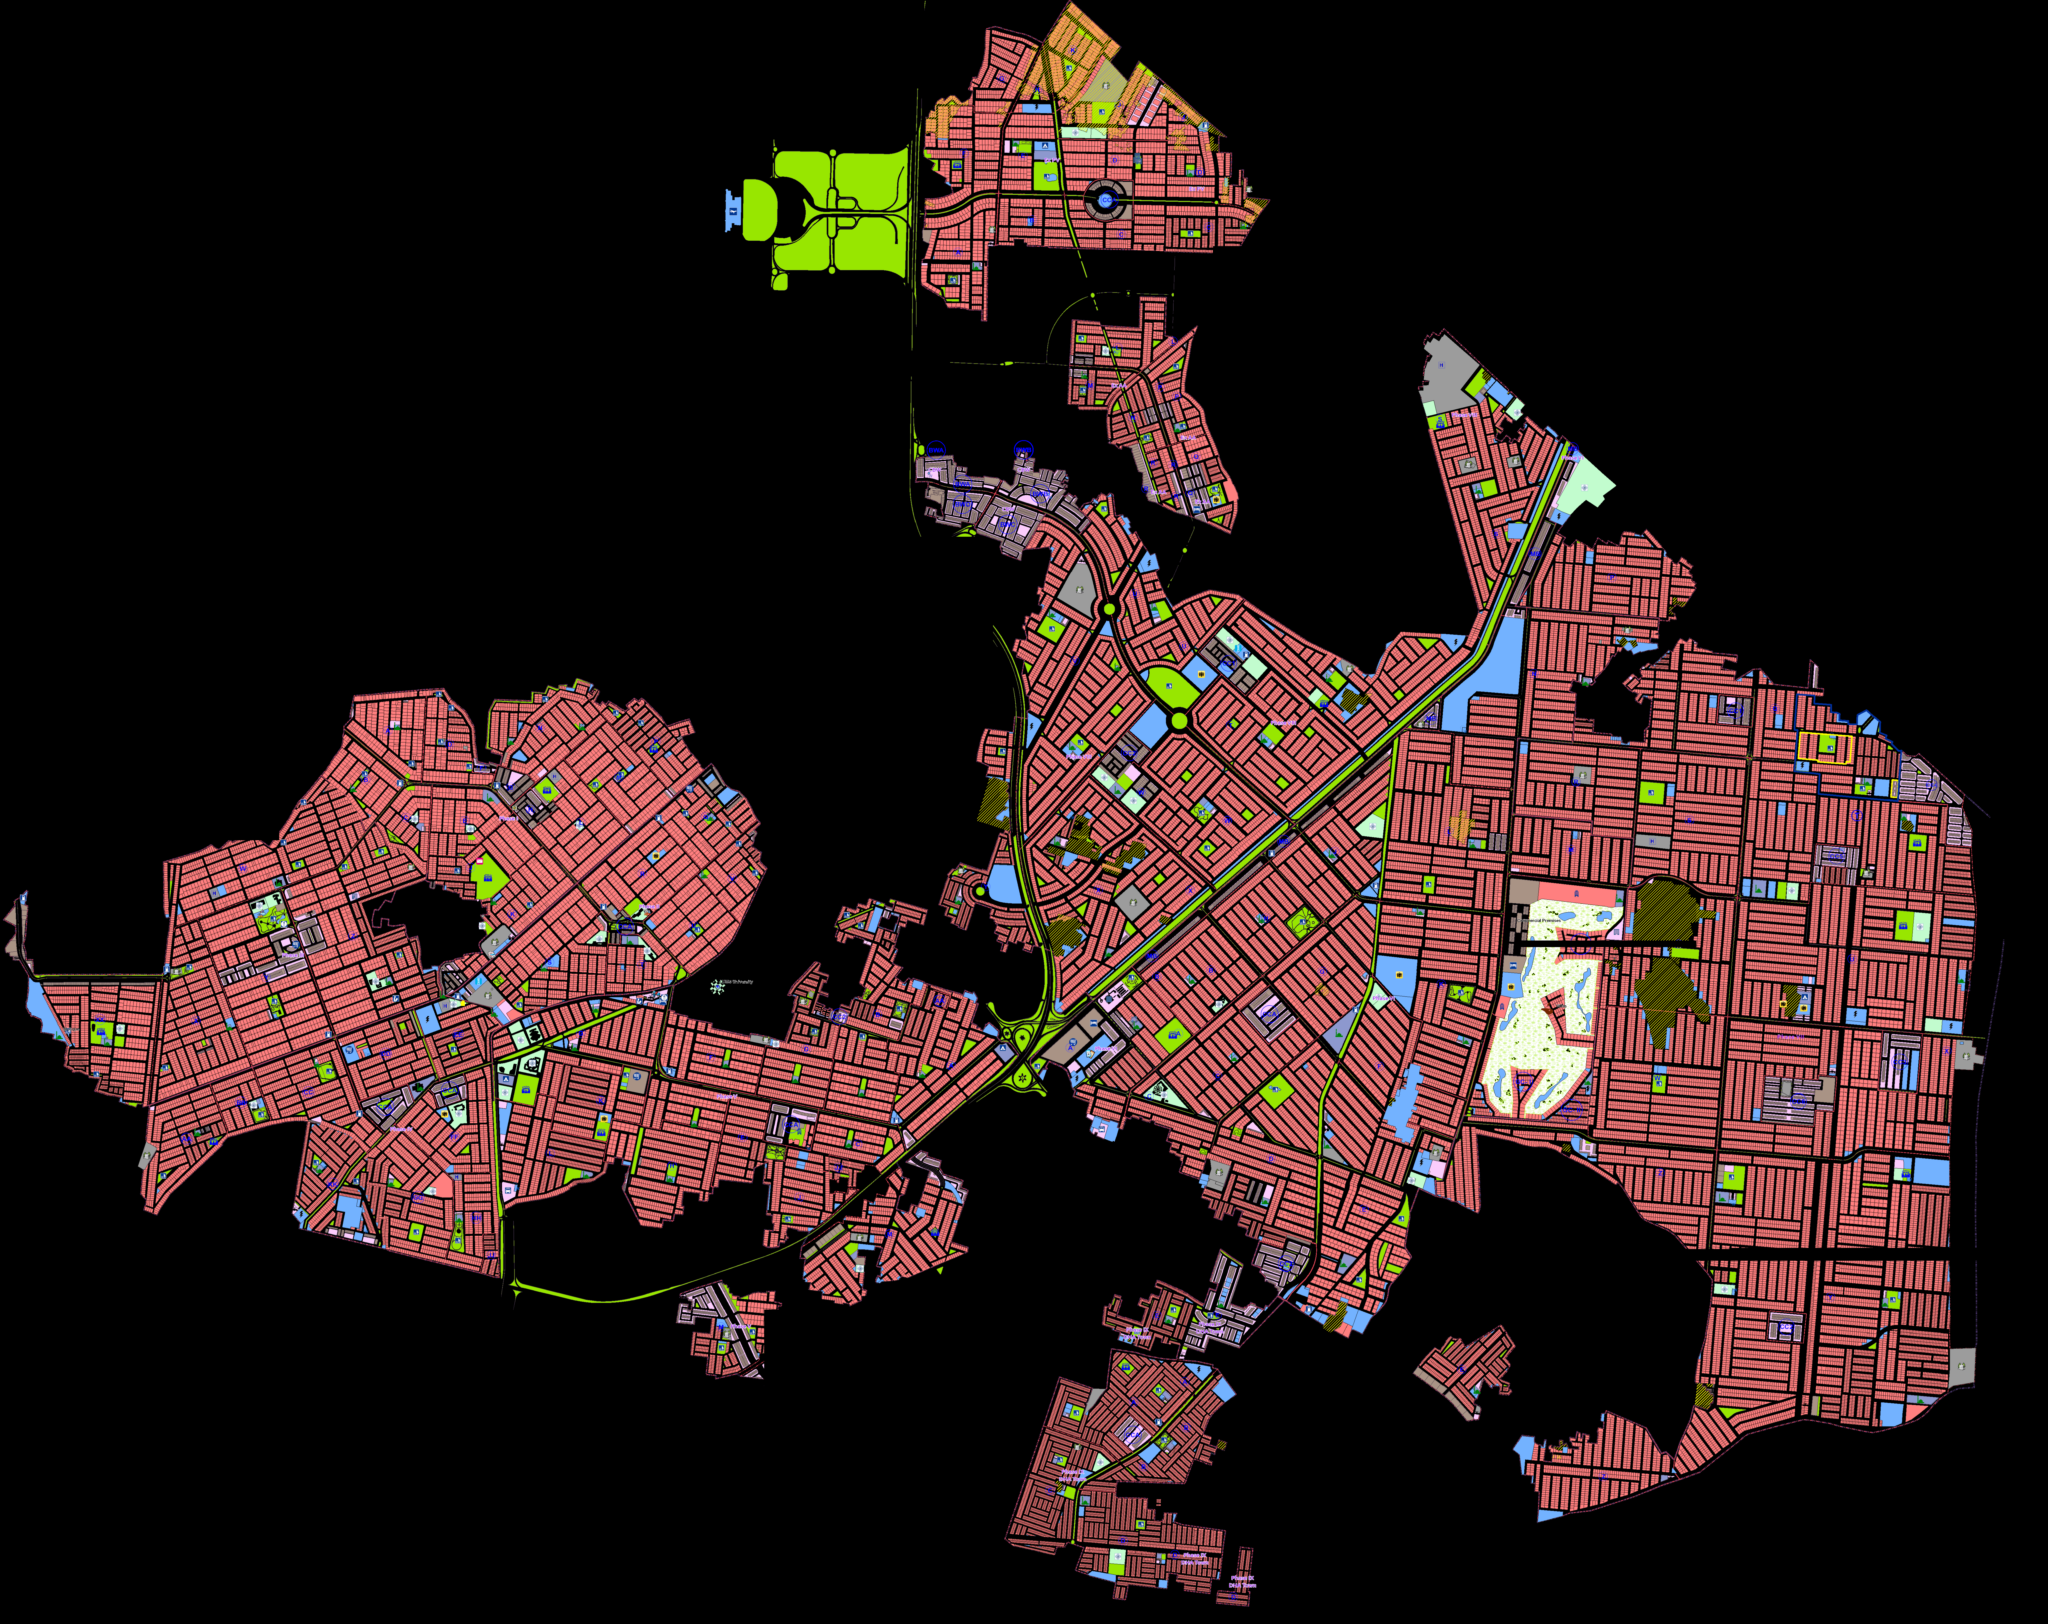

In [13]:
# Overlay the chosen GeoTIFF on a labelled Folium map
import numpy as np
import folium
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject, transform_bounds

if 'TIF_CHOSEN' not in globals() or TIF_CHOSEN is None:
    raise RuntimeError('No GeoTIFF selected (run the discovery cell first).')

OUTPUT_TIF_MAP = ROOT / 'tif_overlay_map.html'

with rio.open(TIF_CHOSEN) as src:
    src_crs = src.crs
    dst_crs = 'EPSG:4326'

    # choose an output shape capped at ~2048 px on the longest side for performance
    max_dim = 2048
    scale = max(src.width, src.height) / max_dim
    out_w = max(1, int(src.width / scale))
    out_h = max(1, int(src.height / scale))

    transform, width, height = calculate_default_transform(
        src_crs, dst_crs, src.width, src.height, *src.bounds, dst_width=out_w, dst_height=out_h
    )

    # Prepare destination arrays (RGB)
    bands = min(3, src.count)
    dst = np.zeros((bands, height, width), dtype=np.uint8)

    # Reproject first 3 bands to EPSG:4326 and scale to 0-255 uint8 if needed
    for b in range(bands):
        src_band = src.read(b+1, out_dtype='float32')
        # scale if values are not 0-255
        sb_min, sb_max = float(np.nanmin(src_band)), float(np.nanmax(src_band))
        if sb_max > 255.0 or sb_min < 0.0:
            # robust normalization
            rng = (np.nanpercentile(src_band, 2), np.nanpercentile(src_band, 98))
            src_band = np.clip((src_band - rng[0]) / max(rng[1]-rng[0], 1e-6), 0, 1) * 255.0
        reproject(
            source=src_band,
            destination=dst[b],
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )
        dst[b] = np.clip(dst[b], 0, 255).astype(np.uint8)

    # Optional alpha
    alpha = None
    if src.count >= 4:
        a_src = src.read(4, out_dtype='float32')
        reproject(
            source=a_src,
            destination=(a_src := np.zeros((height, width), dtype=np.float32)),
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )
        a_norm = np.clip(a_src, 0, 255).astype(np.uint8)
        alpha = a_norm
    else:
        # derive alpha from nonzero pixels
        alpha = (dst.max(axis=0) > 0).astype(np.uint8) * 255

    # Compose HxWx3 uint8
    img = np.transpose(dst, (1, 2, 0))

    # Compute geographic bounds in lat/lon
    l, b, r, t = transform_bounds(src_crs, dst_crs, *src.bounds, densify_pts=21)
    bounds = [[b, l], [t, r]]  # [[south, west], [north, east]]

# Build Folium map with base tiles + label-only overlay
center = [(bounds[0][0] + bounds[1][0]) / 2.0, (bounds[0][1] + bounds[1][1]) / 2.0]
m = folium.Map(location=center, zoom_start=13, tiles=None)

folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png',
    attr='&copy; OpenStreetMap contributors &copy; CARTO',
    name='Basemap (no labels)'
).add_to(m)

folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}{r}.png',
    attr='&copy; OpenStreetMap contributors &copy; CARTO',
    name='Labels',
    overlay=True
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=img,
    bounds=bounds,
    opacity=0.8,
    name=TIF_CHOSEN.name,
    interactive=False,
    cross_origin=False
).add_to(m)

# Put labels layer on top
for child in list(m._children.values()):
    if isinstance(child, folium.raster_layers.TileLayer) and 'Labels' in getattr(child, 'layer_name', ''):
        m.add_child(child)

folium.LayerControl(collapsed=False).add_to(m)

m.save(str(OUTPUT_TIF_MAP))
m

In [14]:
# Inspect DHA shapefile attributes for phase/name labels (lightweight)
import fiona
from pathlib import Path
from collections import Counter

ROOT = Path('..').resolve()
DHA_DIR = ROOT / 'societies' / 'DHA'

attr_counts = Counter()
samples = {}

for shp in DHA_DIR.rglob('*.shp'):
    try:
        with fiona.open(shp) as src:
            schema = src.schema
            props = schema.get('properties', {})
            lower_keys = {k.lower(): k for k in props.keys()}
            # look for likely label fields
            for key in list(lower_keys.keys()):
                if any(hint in key for hint in ['phase', 'name', 'label', 'sector', 'block', 'phase_no']):
                    attr_counts[key] += 1
            # store one sample record of props
            try:
                rec = next(iter(src))
                samples[str(shp)] = {k: rec['properties'].get(k) for k in list(props.keys())[:10]}
            except StopIteration:
                pass
    except Exception as e:
        print('Skip', shp.name, '->', e)

print('Potential label fields seen (lower-case names):', attr_counts)
print('Example property samples from a few files:')
for i, (path, props) in enumerate(samples.items()):
    if i >= 5:
        break
    print('-', path)
    print(' ', props)


Potential label fields seen (lower-case names): Counter()
Example property samples from a few files:
- D:\LUMS\Senior Fall 25\SPROJ - Dr Tahir\SPROJ\societies\DHA\Merged_PCT_Vectorized.shp
  {'DN': 8, 'Area': 57.853}
- D:\LUMS\Senior Fall 25\SPROJ - Dr Tahir\SPROJ\societies\DHA\Split_Areas\DHA_AREA_Split.shp
  {'id': 1}


In [ ]:
# Folium map: DHA Phase rasters + Private Schemes polygons
import os
from pathlib import Path
import numpy as np
import folium
import geopandas as gpd
import pandas as pd
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject, transform_bounds

# Paths
ROOT = Path('..').resolve()
DHA_PHASES_DIR = ROOT / 'societies' / 'DHA' / 'Georefrenced_Rasters'
PRIVATE_SCHEMES_DIR = ROOT / 'societies' / 'Private Schemes'
OUTPUT_HTML = ROOT / 'dha_phases_private_schemes_map.html'

# Collect all phase rasters (*.tif)
phase_tifs = []
if DHA_PHASES_DIR.exists():
    for p in DHA_PHASES_DIR.rglob('*.tif'):
        phase_tifs.append(p)

# Helper: reproject single TIFF to 4326 and downsample to max_dim
def reproject_tif_to_img_and_bounds(tif_path, max_dim=1500):
    with rio.open(tif_path) as src:
        src_crs = src.crs
        dst_crs = 'EPSG:4326'
        scale = max(src.width, src.height) / max_dim
        out_w = max(1, int(src.width / scale))
        out_h = max(1, int(src.height / scale))

        transform, width, height = calculate_default_transform(
            src_crs, dst_crs, src.width, src.height, *src.bounds, dst_width=out_w, dst_height=out_h
        )

        bands = min(3, src.count)
        dst = np.zeros((bands, height, width), dtype=np.uint8)

        for b in range(bands):
            src_band = src.read(b+1, out_dtype='float32')
            # robust normalization if needed
            sb_min, sb_max = float(np.nanmin(src_band)), float(np.nanmax(src_band))
            if sb_max > 255.0 or sb_min < 0.0:
                lo, hi = np.nanpercentile(src_band, 2), np.nanpercentile(src_band, 98)
                src_band = np.clip((src_band - lo) / max(hi - lo, 1e-6), 0, 1) * 255.0
            reproject(
                source=src_band,
                destination=dst[b],
                src_transform=src.transform,
                src_crs=src_crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
            )
            dst[b] = np.clip(dst[b], 0, 255).astype(np.uint8)

        img = np.transpose(dst, (1, 2, 0))  # HxWx3
        l, b, r, t = transform_bounds(src_crs, dst_crs, *src.bounds, densify_pts=21)
        bounds = [[b, l], [t, r]]
        return img, bounds

# Build map base with labels
if phase_tifs:
    # Center using first raster bounds
    first_img, first_bounds = reproject_tif_to_img_and_bounds(phase_tifs[0], max_dim=1500)
    center = [(first_bounds[0][0] + first_bounds[1][0]) / 2.0, (first_bounds[0][1] + first_bounds[1][1]) / 2.0]
else:
    center = [31.5204, 74.3587]

m = folium.Map(location=center, zoom_start=12, tiles=None)
folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png',
    attr='&copy; OpenStreetMap contributors &copy; CARTO',
    name='Basemap (no labels)'
).add_to(m)
folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}{r}.png',
    attr='&copy; OpenStreetMap contributors &copy; CARTO',
    name='Labels',
    overlay=True
).add_to(m)

# Add each phase raster as a togglable overlay (default off)
for tif in phase_tifs:
    try:
        img, bounds = reproject_tif_to_img_and_bounds(tif, max_dim=1500)
        layer_name = f"DHA Phase Raster: {tif.stem}"
        grp = folium.FeatureGroup(name=layer_name, show=False)
        folium.raster_layers.ImageOverlay(
            image=img,
            bounds=bounds,
            opacity=0.8,
            interactive=False,
            cross_origin=False
        ).add_to(grp)
        grp.add_to(m)
    except Exception as e:
        print('Skip raster', tif.name, '->', e)

# Load Private Schemes polygons
ps_frames = []
if PRIVATE_SCHEMES_DIR.exists():
    for root, dirs, files in os.walk(PRIVATE_SCHEMES_DIR):
        for f in files:
            if f.lower().endswith('.shp'):
                shp = Path(root) / f
                try:
                    gdf = gpd.read_file(shp)
                    if gdf.crs is None:
                        # assume WGS84 if missing
                        gdf = gdf.set_crs(4326, allow_override=True)
                    else:
                        gdf = gdf.to_crs(4326)
                    # derive scheme label from folder name after 'Private Schemes'
                    rel = shp.relative_to(PRIVATE_SCHEMES_DIR)
                    scheme = rel.parts[0] if len(rel.parts) > 0 else shp.stem
                    gdf['scheme_label'] = scheme
                    # keep only needed cols
                    gdf = gdf[['scheme_label', 'geometry']]
                    # simplify for web
                    try:
                        gdf = gdf.to_crs(3857)
                        gdf['geometry'] = gdf.geometry.simplify(8)  # ~8 meters tolerance
                        gdf = gdf.to_crs(4326)
                    except Exception:
                        pass
                    ps_frames.append(gdf)
                except Exception as e:
                    print('Skip PS shapefile', shp.name, '->', e)

if ps_frames:
    ps_gdf = gpd.GeoDataFrame(pd.concat(ps_frames, ignore_index=True), crs='EPSG:4326')
    # Filter invalid/empty
    ps_gdf = ps_gdf[ps_gdf.geometry.notnull() & ps_gdf.is_valid]
    # Add as GeoJson overlay
    folium.GeoJson(
        ps_gdf,
        name='Private Schemes',
        style_function=lambda feat: {
            'fillOpacity': 0.05,
            'weight': 1,
            'color': '#1f77b4'
        },
        tooltip=folium.features.GeoJsonTooltip(fields=['scheme_label'], aliases=['Scheme'])
    ).add_to(m)
else:
    print('No Private Schemes polygons found.')

folium.LayerControl(collapsed=False).add_to(m)

m.save(str(OUTPUT_HTML))
m